https://colab.research.google.com/drive/1Vjh_cqgJJKdzB8UsDcvzNqZt4qWVEup2?usp=sharing


# Exploratory Data Analysis and Hypothesis Testing
**Score-Based Popularity Prediction in Classical Music**
DSA 210 — Spring 2025–2026

---

## 1. Data Collection Summary

### 1.1 Source Corpus
MIDI files were sourced from the `drengskapur/midi-classical-music` dataset on HuggingFace (~4,500 files). After manual curation for encoding consistency and verified composer attribution, we retained **961 pieces** across **18 composers** and **5 musical eras** (Baroque, Classical, Romantic, Late Romantic, Impressionist).

### 1.2 Popularity Ground Truth
Popularity was measured via the Spotify Web API. For each piece, we searched recordings by title and composer, collected popularity scores (0–100) for all matching tracks, and took the **maximum** popularity across all recordings. The maximum was chosen to isolate score-level signal by absorbing variation from performer fame and algorithmic amplification into the "unexplained" portion.

### 1.3 Corpus Balancing
To prevent models from learning "composer X = popular," each composer was capped at 100 pieces and pieces were selected to span each composer's full popularity range when possible. Final corpus: **961 pieces**, **18 composers**, **5 eras**.

### 1.4 Feature Extraction
We extracted **65 features** from each MIDI file using the `music21` library:
- **25 static features**: 8 tonal, 6 temporal, 11 harmonic/structural
- **40 temporal evolution features**: 8 base features × 4 quartiles + 8 slopes

## 2. Setup and Data Loading

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

In [ ]:
# Load static features (25) + metadata
static = pd.read_csv('data/features/balanced_corpus_v2.csv')

# Load temporal features (40)
temporal = pd.read_csv('data/features/temporal_features.csv')

# Merge into full 65-feature dataset
df = static.merge(
    temporal.drop(columns=['composer', 'popularity'], errors='ignore'),
    on='piece_id', how='inner'
)

# Add era labels
era_map = {
    'bach': 'Baroque', 'vivaldi': 'Baroque', 'handel': 'Baroque',
    'mozart': 'Classical', 'beethoven': 'Classical', 'haydn': 'Classical',
    'chopin': 'Romantic', 'schumann': 'Romantic', 'brahms': 'Romantic',
    'schubert': 'Romantic', 'liszt': 'Romantic', 'mendelssohn': 'Romantic',
    'tchaikovsky': 'Romantic', 'dvorak': 'Romantic', 'grieg': 'Romantic',
    'rachmaninov': 'Late Romantic',
    'debussy': 'Impressionist', 'ravel': 'Impressionist',
}
if 'era' not in df.columns:
    df['era'] = df['composer'].map(era_map)

# Define feature column lists
meta_cols = ['piece_id', 'composer', 'title', 'popularity', 'era']
static_features = [c for c in static.columns if c not in meta_cols]
temporal_features = [c for c in temporal.columns if c not in ['piece_id', 'composer', 'popularity']]
all_features = static_features + temporal_features

print(f"Dataset: {df.shape[0]} pieces x {df.shape[1]} columns")
print(f"Static features: {len(static_features)}")
print(f"Temporal features: {len(temporal_features)}")
print(f"Total features: {len(all_features)}")
print(f"Composers: {df['composer'].nunique()}")
print(f"Eras: {df['era'].nunique()}")

Dataset: 961 pieces x 74 columns
Static features: 29
Temporal features: 40
Total features: 69
Composers: 18
Eras: 5


### 2.1 Data Quality Check

In [ ]:
# Check for missing values
missing = df[all_features].isnull().sum()
features_with_missing = missing[missing > 0]

if len(features_with_missing) > 0:
    print("Features with missing values:")
    for feat, count in features_with_missing.items():
        print(f"  {feat}: {count} missing ({count/len(df)*100:.1f}%)")
else:
    print("No missing values in any feature.")

print(f"\nTotal missing values: {missing.sum()} across {len(all_features)} features")

Features with missing values:
  duration: 55 missing (5.7%)
  note_density: 55 missing (5.7%)

Total missing values: 110 across 69 features


---
## 3. Exploratory Data Analysis

### 3.1 Popularity Distribution

In [ ]:
pop = df['popularity']

print("Popularity Distribution Summary")
print("=" * 35)
print(f"  Mean:      {pop.mean():.2f}")
print(f"  Median:    {pop.median():.2f}")
print(f"  Std Dev:   {pop.std():.2f}")
print(f"  Min / Max: {pop.min()} / {pop.max()}")
print(f"  Q1 / Q3:   {pop.quantile(0.25):.1f} / {pop.quantile(0.75):.1f}")
print(f"  IQR:       {pop.quantile(0.75) - pop.quantile(0.25):.1f}")
print(f"  Skewness:  {pop.skew():.3f}")
print(f"  Kurtosis:  {pop.kurtosis():.3f}")

Popularity Distribution Summary
  Mean:      54.04
  Median:    54.00
  Std Dev:   11.73
  Min / Max: 5 / 88
  Q1 / Q3:   45.0 / 65.0
  IQR:       20.0
  Skewness:  -0.377
  Kurtosis:  0.335


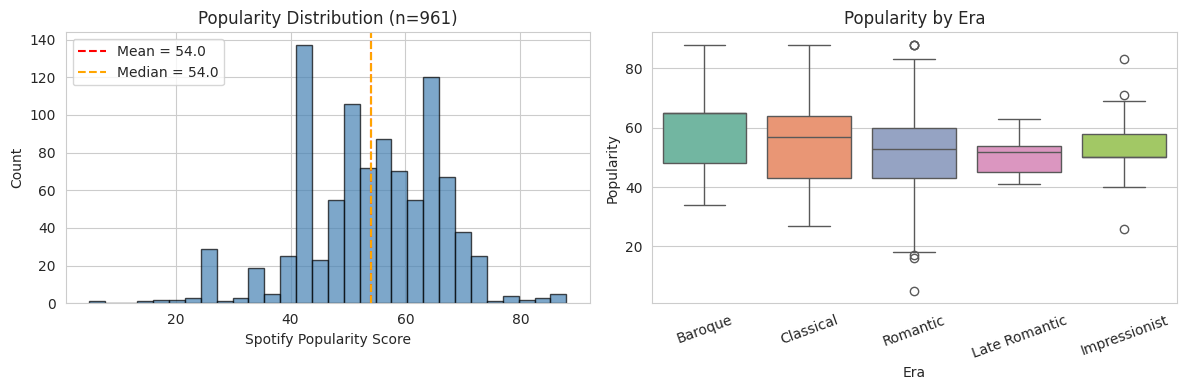

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(df['popularity'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(pop.mean(), color='red', linestyle='--', label=f'Mean = {pop.mean():.1f}')
axes[0].axvline(pop.median(), color='orange', linestyle='--', label=f'Median = {pop.median():.1f}')
axes[0].set_xlabel('Spotify Popularity Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Popularity Distribution (n=961)')
axes[0].legend()

# Box plot by era
era_order = ['Baroque', 'Classical', 'Romantic', 'Late Romantic', 'Impressionist']
sns.boxplot(data=df, x='era', y='popularity', order=era_order, ax=axes[1], palette='Set2')
axes[1].set_xlabel('Era')
axes[1].set_ylabel('Popularity')
axes[1].set_title('Popularity by Era')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

### 3.2 Popularity by Composer

In [ ]:
comp_stats = df.groupby('composer').agg(
    era=('era', 'first'),
    n=('popularity', 'count'),
    mean=('popularity', 'mean'),
    median=('popularity', 'median'),
    std=('popularity', 'std')
).sort_values('mean', ascending=False).round(2)

print(comp_stats.to_string())

                       era    n   mean  median    std
composer                                             
tchaikovsky       Romantic   16  67.69    72.0   8.06
bach               Baroque  100  65.67    65.0   2.58
mendelssohn       Romantic   10  64.20    66.0   9.51
mozart           Classical  100  61.82    61.0   4.73
beethoven        Classical  100  57.67    54.0   7.59
grieg             Romantic   15  57.27    55.0  13.69
chopin            Romantic   99  55.40    55.0   7.10
debussy      Impressionist   17  53.94    57.0  11.25
schumann          Romantic   61  53.90    55.0  13.95
ravel        Impressionist   14  52.79    50.0   9.79
dvorak            Romantic   15  52.20    52.0  13.40
rachmaninov  Late Romantic   34  51.09    52.0   7.71
liszt             Romantic   28  50.71    51.0  13.98
brahms            Romantic   60  49.32    53.0  13.32
schubert          Romantic  100  49.26    43.0   9.75
vivaldi            Baroque  100  48.43    48.0   6.65
handel             Baroque  

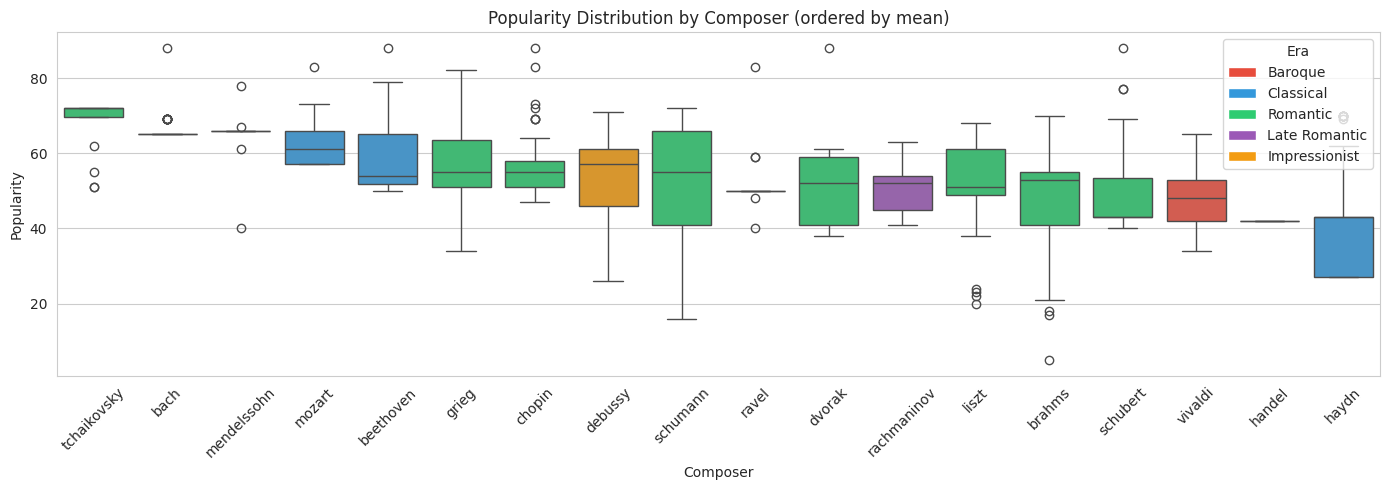

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))

composer_order = comp_stats.index.tolist()
era_colors = {'Baroque': '#e74c3c', 'Classical': '#3498db', 'Romantic': '#2ecc71',
              'Late Romantic': '#9b59b6', 'Impressionist': '#f39c12'}
colors = [era_colors[comp_stats.loc[c, 'era']] for c in composer_order]

sns.boxplot(data=df, x='composer', y='popularity', order=composer_order,
            palette=colors, ax=ax)
ax.set_xlabel('Composer')
ax.set_ylabel('Popularity')
ax.set_title('Popularity Distribution by Composer (ordered by mean)')
ax.tick_params(axis='x', rotation=45)

# Legend for eras
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=e) for e, c in era_colors.items()]
ax.legend(handles=legend_elements, loc='upper right', title='Era')

plt.tight_layout()
plt.show()

**Observations:**
- Composer mean popularity ranges from 40.62 (Haydn) to 67.69 (Tchaikovsky), a span of 27 points.
- Within-composer variance differs dramatically: Bach's std is only 2.58 (almost all pieces share similar popularity), while Haydn's is 13.30 (wide internal spread).
- 83% of tracks share a popularity score with at least two other tracks by the same composer, which confirm composer identity as a dominant confound.

### 3.3 Feature–Popularity Correlations

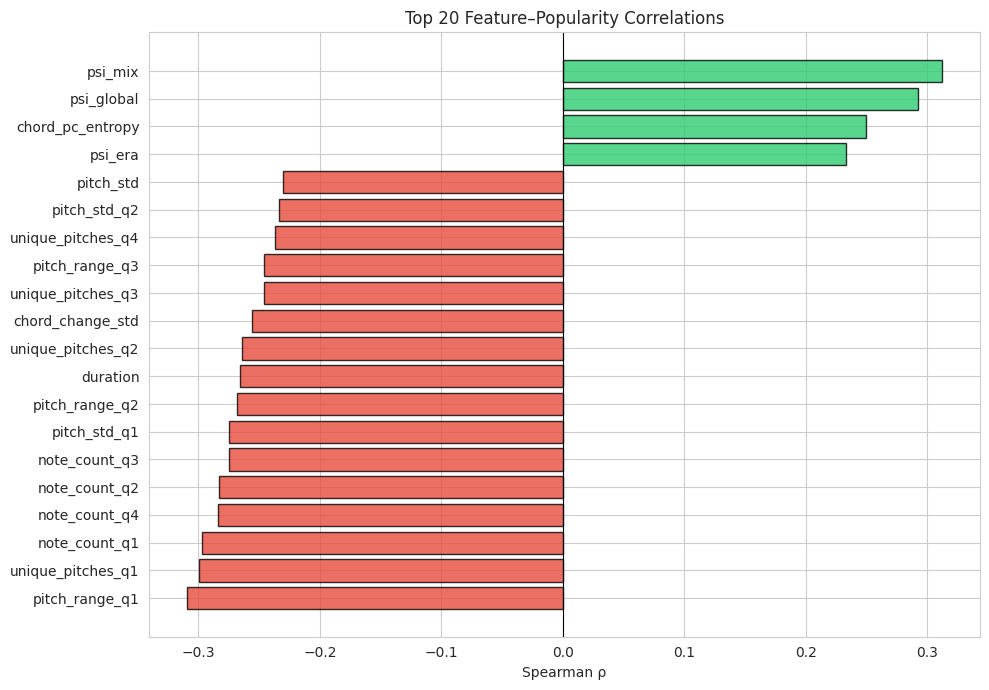

In [ ]:
# Compute Spearman correlations for all 65 features
corr_results = []
for feat in all_features:
    vals = df[[feat, 'popularity']].dropna()
    r, p = stats.spearmanr(vals[feat], vals['popularity'])
    corr_results.append({'feature': feat, 'rho': r, 'p': p,
                         'type': 'static' if feat in static_features else 'temporal'})

corr_df = pd.DataFrame(corr_results).sort_values('rho', key=abs, ascending=False)
corr_df['abs_rho'] = corr_df['rho'].abs()

# Plot top 20
top_corr = corr_df.head(20).sort_values('rho')
colors = ['#e74c3c' if r < 0 else '#2ecc71' for r in top_corr['rho']]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_corr['feature'], top_corr['rho'], color=colors, edgecolor='black', alpha=0.8)
ax.set_xlabel('Spearman ρ')
ax.set_title('Top 20 Feature–Popularity Correlations')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

### 3.4 Static Feature Correlation Matrix

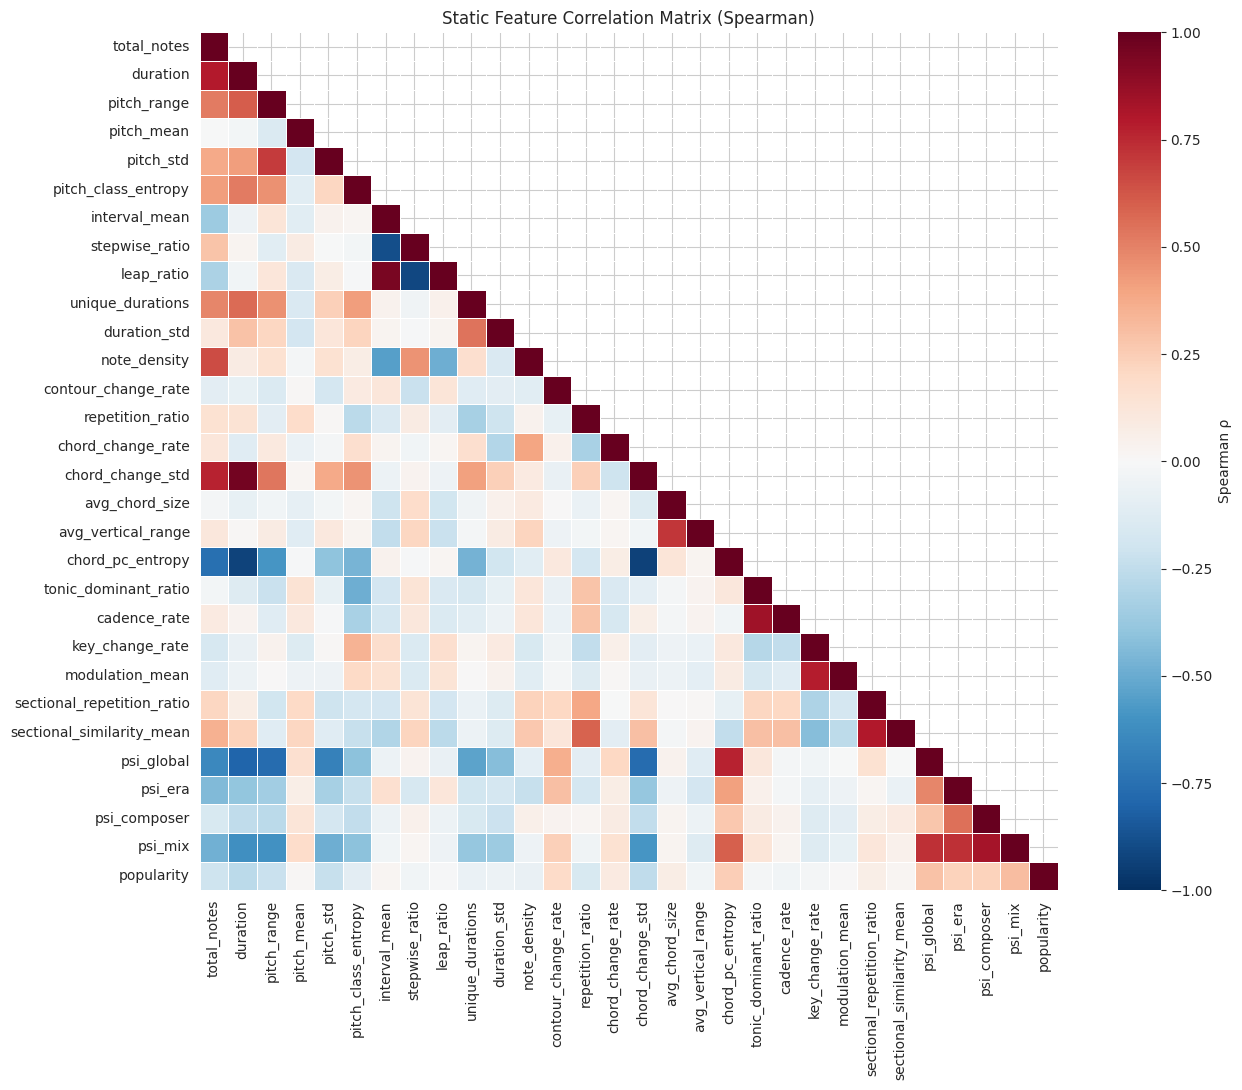

In [ ]:
# Correlation matrix for static features + popularity
corr_cols = static_features + ['popularity']
corr_matrix = df[corr_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=False, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Spearman ρ'})
ax.set_title('Static Feature Correlation Matrix (Spearman)')
plt.tight_layout()
plt.show()

---
## 4. Hypothesis Tests

All hypothesis tests use non-parametric methods, justified by the non-normality of the popularity distribution (Test 1). Significance level α = 0.05 throughout, with Bonferroni correction applied for multiple comparisons.

### Test 1: Normality of Popularity Distribution

- **H₀:** Popularity scores follow a normal distribution.
- **H₁:** Popularity scores do not follow a normal distribution.
- **Method:** Shapiro-Wilk test.

In [ ]:
w, p = stats.shapiro(df['popularity'])

print(f"Shapiro-Wilk Test")
print(f"  W statistic = {w:.6f}")
print(f"  p-value     = {p:.2e}")
print(f"  Decision:   {'Reject H0' if p < 0.05 else 'Fail to reject H0'} at α = 0.05")
print(f"\nPopularity is NOT normally distributed (p < 0.001).")
print(f"This justifies non-parametric methods for all subsequent tests.")

Shapiro-Wilk Test
  W statistic = 0.975473
  p-value     = 1.18e-11
  Decision:   Reject H0 at α = 0.05

Popularity is NOT normally distributed (p < 0.001).
This justifies non-parametric methods for all subsequent tests.


### Test 2: Popularity Differs Across Composers

- **H₀:** Popularity distributions are identical across composers.
- **H₁:** At least one composer's popularity distribution differs.
- **Method:** Kruskal-Wallis H test (17 composers with ≥ 10 pieces; Handel excluded, n=1).

In [ ]:
# Only include composers with >= 10 pieces
counts = df['composer'].value_counts()
valid_composers = counts[counts >= 10].index
groups = [df[df['composer'] == c]['popularity'].values for c in valid_composers]

h, p = stats.kruskal(*groups)
n_total = sum(len(g) for g in groups)
eta_sq = (h - len(groups) + 1) / (n_total - len(groups))

print(f"Kruskal-Wallis Test (Popularity ~ Composer)")
print(f"  Groups:      {len(groups)} composers (≥ 10 pieces each)")
print(f"  H statistic: {h:.4f}")
print(f"  p-value:     {p:.2e}")
print(f"  η² (effect): {eta_sq:.4f} — large effect (> 0.14)")
print(f"  Decision:    Reject H0 (p < 0.001)")
print(f"\nComposer identity explains ~{eta_sq*100:.1f}% of rank-variance in popularity.")

Kruskal-Wallis Test (Popularity ~ Composer)
  Groups:      17 composers (≥ 10 pieces each)
  H statistic: 377.1960
  p-value:     2.17e-70
  η² (effect): 0.3830 — large effect (> 0.14)
  Decision:    Reject H0 (p < 0.001)

Composer identity explains ~38.3% of rank-variance in popularity.


### Test 3: Popularity Differs Across Eras

- **H₀:** Popularity distributions are identical across eras.
- **H₁:** At least one era's popularity distribution differs.
- **Method:** Kruskal-Wallis H test (5 era groups), with post-hoc pairwise Mann-Whitney (Bonferroni-corrected).

In [ ]:
eras = sorted(df['era'].unique())
era_groups = [df[df['era'] == e]['popularity'].values for e in eras]

h, p = stats.kruskal(*era_groups)
n_total = sum(len(g) for g in era_groups)
eta_sq = (h - len(era_groups) + 1) / (n_total - len(era_groups))

print(f"Kruskal-Wallis Test (Popularity ~ Era)")
print(f"  Groups:      {len(era_groups)} eras")
print(f"  H statistic: {h:.4f}")
print(f"  p-value:     {p:.2e}")
print(f"  η² (effect): {eta_sq:.4f} — small effect (< 0.06)")
print(f"  Decision:    {'Reject H0' if p < 0.05 else 'Fail to reject H0'} at α = 0.05")

# Post-hoc pairwise comparisons
print(f"\nPost-hoc pairwise Mann-Whitney U (Bonferroni-corrected):")
pairs = list(combinations(eras, 2))
n_pairs = len(pairs)

posthoc_results = []
for e1, e2 in pairs:
    g1 = df[df['era'] == e1]['popularity']
    g2 = df[df['era'] == e2]['popularity']
    u, p_mw = stats.mannwhitneyu(g1, g2, alternative='two-sided')
    p_adj = min(p_mw * n_pairs, 1.0)
    sig = "***" if p_adj < 0.001 else "**" if p_adj < 0.01 else "*" if p_adj < 0.05 else "ns"
    posthoc_results.append({'era_1': e1, 'era_2': e2, 'U': u, 'p_adj': p_adj, 'sig': sig})
    print(f"  {e1:20s} vs {e2:20s}: U={u:8.0f}  p_adj={p_adj:.4f}  {sig}")

print(f"\nOnly Baroque vs Late Romantic and Baroque vs Romantic are significant.")
print(f"Era alone carries minimal predictive information compared to composer identity.")

Kruskal-Wallis Test (Popularity ~ Era)
  Groups:      5 eras
  H statistic: 18.1697
  p-value:     1.14e-03
  η² (effect): 0.0148 — small effect (< 0.06)
  Decision:    Reject H0 at α = 0.05

Post-hoc pairwise Mann-Whitney U (Bonferroni-corrected):
  Baroque              vs Classical           : U=   32303  p_adj=0.4728  ns
  Baroque              vs Impressionist       : U=    3816  p_adj=0.3791  ns
  Baroque              vs Late Romantic       : U=    4734  p_adj=0.0022  **
  Baroque              vs Romantic            : U=   47449  p_adj=0.0070  **
  Classical            vs Impressionist       : U=    5071  p_adj=1.0000  ns
  Classical            vs Late Romantic       : U=    6027  p_adj=0.3690  ns
  Classical            vs Romantic            : U=   63686  p_adj=0.5998  ns
  Impressionist        vs Late Romantic       : U=     605  p_adj=1.0000  ns
  Impressionist        vs Romantic            : U=    6243  p_adj=1.0000  ns
  Late Romantic        vs Romantic            : U=    6152

### Test 4: Feature–Popularity Correlations (Bonferroni-Corrected)

- **H₀ (per feature):** No monotonic association between the feature and popularity.
- **H₁ (per feature):** A monotonic association exists.
- **Method:** Spearman rank correlation with Bonferroni correction (65 tests, adjusted α = 0.05/65 ≈ 7.69 × 10⁻⁴).

In [ ]:
n_tests = len(all_features)
alpha_adj = 0.05 / n_tests

results = []
for feat in all_features:
    vals = df[[feat, 'popularity']].dropna()
    r, p = stats.spearmanr(vals[feat], vals['popularity'])
    p_bonf = min(p * n_tests, 1.0)
    results.append({'feature': feat, 'rho': r, 'p_raw': p, 'p_bonf': p_bonf,
                    'type': 'static' if feat in static_features else 'temporal'})

spearman_df = pd.DataFrame(results).sort_values('rho', key=abs, ascending=False)
spearman_df['sig'] = spearman_df['p_bonf'].apply(
    lambda p: '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns')

n_sig = (spearman_df['p_bonf'] < 0.05).sum()
print(f"Bonferroni-corrected threshold: α = {alpha_adj:.6f}")
print(f"Significant features: {n_sig}/{n_tests}\n")

print(f"{'Feature':35s} {'ρ':>8s} {'p (Bonf.)':>12s} {'Sig':>4s}")
print("-" * 63)
for _, row in spearman_df.head(20).iterrows():
    print(f"{row['feature']:35s} {row['rho']:+8.4f} {row['p_bonf']:12.2e} {row['sig']:>4s}")

Bonferroni-corrected threshold: α = 0.000725
Significant features: 37/69

Feature                                    ρ    p (Bonf.)  Sig
---------------------------------------------------------------
psi_mix                              +0.3124     2.36e-21  ***
pitch_range_q1                       -0.3094     6.31e-21  ***
unique_pitches_q1                    -0.2995     1.58e-19  ***
note_count_q1                        -0.2972     3.30e-19  ***
psi_global                           +0.2922     1.58e-18  ***
note_count_q4                        -0.2842     1.77e-17  ***
note_count_q2                        -0.2829     2.63e-17  ***
note_count_q3                        -0.2752     2.55e-16  ***
pitch_std_q1                         -0.2748     2.86e-16  ***
pitch_range_q2                       -0.2684     1.78e-15  ***
duration                             -0.2662     2.55e-14  ***
unique_pitches_q2                    -0.2643     5.48e-15  ***
chord_change_std                     -0.255

**Key finding:** 34 of 65 features are significantly correlated with popularity after Bonferroni correction, but all individual correlations are modest (|ρ| ≤ 0.31). No single feature is a strong predictor. The temporal features (quartile-specific) dominate the top of the list, suggesting how a piece starts matters more than its average properties.

### Test 5: Feature Differences Between Popular and Non-Popular Pieces

- **H₀ (per feature):** Feature distribution is identical for top-quartile and remaining pieces.
- **H₁ (per feature):** The distributions differ.
- **Method:** Mann-Whitney U test with Bonferroni correction (25 static features, adjusted α = 0.002).

In [ ]:
q75 = df['popularity'].quantile(0.75)
top = df[df['popularity'] >= q75]
rest = df[df['popularity'] < q75]
n_tests_mw = len(static_features)

print(f"Top quartile:  {len(top)} pieces (popularity ≥ {q75})")
print(f"Rest:          {len(rest)} pieces")
print(f"Bonferroni α = 0.05 / {n_tests_mw} = {0.05/n_tests_mw:.4f}\n")

mw_results = []
for feat in static_features:
    t_vals = top[feat].dropna()
    r_vals = rest[feat].dropna()
    u, p = stats.mannwhitneyu(t_vals, r_vals, alternative='two-sided')
    r_rb = 1 - (2 * u) / (len(t_vals) * len(r_vals))
    p_bonf = min(p * n_tests_mw, 1.0)
    sig = '***' if p_bonf < 0.001 else '**' if p_bonf < 0.01 else '*' if p_bonf < 0.05 else 'ns'
    mw_results.append({'feature': feat, 'U': u, 'r_rb': r_rb, 'p_bonf': p_bonf, 'sig': sig})

mw_df = pd.DataFrame(mw_results).sort_values('p_bonf')
n_sig = (mw_df['p_bonf'] < 0.05).sum()

print(f"{'Feature':30s} {'U':>10s} {'r (rank-bis.)':>14s} {'p (Bonf.)':>12s} {'Sig':>4s}")
print("-" * 74)
for _, row in mw_df.iterrows():
    print(f"{row['feature']:30s} {row['U']:10.0f} {row['r_rb']:+14.3f} {row['p_bonf']:12.2e} {row['sig']:>4s}")

print(f"\nSignificant after Bonferroni: {n_sig}/{n_tests_mw} features")

Top quartile:  253 pieces (popularity ≥ 65.0)
Rest:          708 pieces
Bonferroni α = 0.05 / 29 = 0.0017

Feature                                 U  r (rank-bis.)    p (Bonf.)  Sig
--------------------------------------------------------------------------
psi_mix                            137742         -0.538     1.43e-35  ***
psi_global                         130678         -0.459     5.77e-26  ***
psi_composer                       127602         -0.425     3.00e-22  ***
psi_era                            126768         -0.415     2.73e-21  ***
pitch_range                         57813         +0.354     1.50e-15  ***
pitch_std                           58442         +0.347     6.29e-15  ***
duration                            52677         +0.349     1.77e-14  ***
chord_pc_entropy                   118594         -0.324     5.34e-13  ***
chord_change_std                    60906         +0.320     1.15e-12  ***
contour_change_rate                117970         -0.317     1.90e-1

**Key finding:** 12 of 25 static features are significantly different between top-quartile and non-top-quartile pieces. The rank-biserial correlations are moderate (0.18–0.35), confirming that no single feature separates the groups cleanly but suggesting a multivariate approach may yield meaningful discrimination.

### Test 6: Feature–Popularity Relationships Vary Across Eras

- **H₀:** The Spearman correlation between a feature and popularity is the same across eras.
- **H₁:** The correlation differs.
- **Method:** Within-era Spearman correlations + Fisher z-test comparing the two largest groups (Baroque n=201 vs Romantic n=404).

In [ ]:
key_features = ['chord_change_std', 'duration', 'chord_pc_entropy',
                'pitch_std', 'pitch_range', 'stepwise_ratio',
                'note_density', 'cadence_rate']

eras = sorted(df['era'].unique())

# Within-era correlations table
print("Within-era Spearman correlations (key features):\n")
print(f"{'Feature':25s}" + "".join(f" {e:>18s}" for e in eras))
print("-" * (25 + 18 * len(eras)))

for feat in key_features:
    row = f"{feat:25s}"
    for era in eras:
        sub = df[df['era'] == era][[feat, 'popularity']].dropna()
        r, p = stats.spearmanr(sub[feat], sub['popularity'])
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        row += f" {r:+.3f}{sig:>4s} (n={len(sub):>3d})"
    print(row)

Within-era Spearman correlations (key features):

Feature                              Baroque          Classical      Impressionist      Late Romantic           Romantic
-------------------------------------------------------------------------------------------------------------------
chord_change_std          -0.345 *** (n=201) -0.172  ** (n=291) +0.277     (n= 31) -0.165     (n= 34) -0.333 *** (n=404)
duration                  -0.364 *** (n=196) -0.137   * (n=277) +0.517  ** (n= 26) -0.208     (n= 28) -0.350 *** (n=379)
chord_pc_entropy          +0.354 *** (n=201) +0.179  ** (n=291) -0.253     (n= 31) +0.069     (n= 34) +0.315 *** (n=404)


pitch_std                 -0.518 *** (n=201) -0.154  ** (n=291) +0.266     (n= 31) -0.043     (n= 34) -0.134  ** (n=404)


pitch_range               -0.436 *** (n=201) -0.171  ** (n=291) +0.617 *** (n= 31) -0.235     (n= 34) -0.158  ** (n=404)
stepwise_ratio            -0.138     (n=201) -0.022     (n=291) -0.663 *** (n= 31) -0.089     (n= 34) -0.028     (n=404)
note_density              -0.336 *** (n=196) -0.151   * (n=277) -0.330     (n= 26) -0.163     (n= 28) -0.093     (n=379)
cadence_rate              -0.347 *** (n=201) -0.050     (n=291) +0.085     (n= 31) +0.093     (n= 34) +0.016     (n=404)


In [ ]:
# Fisher z-test: Baroque vs Romantic
baroque = df[df['era'] == 'Baroque']
romantic = df[df['era'] == 'Romantic']

print(f"Fisher z-test: Baroque (n={len(baroque)}) vs Romantic (n={len(romantic)})\n")
print(f"{'Feature':25s} {'ρ (Baroque)':>12s} {'ρ (Romantic)':>13s} {'z':>8s} {'p':>10s} {'Sig':>4s}")
print("-" * 76)

for feat in key_features:
    b_data = baroque[[feat, 'popularity']].dropna()
    r_data = romantic[[feat, 'popularity']].dropna()
    r1, _ = stats.spearmanr(b_data[feat], b_data['popularity'])
    r2, _ = stats.spearmanr(r_data[feat], r_data['popularity'])
    n1, n2 = len(b_data), len(r_data)

    z1, z2 = np.arctanh(r1), np.arctanh(r2)
    se = np.sqrt(1 / (n1 - 3) + 1 / (n2 - 3))
    z_diff = (z1 - z2) / se
    p_diff = 2 * (1 - stats.norm.cdf(abs(z_diff)))
    sig = '***' if p_diff < 0.001 else '**' if p_diff < 0.01 else '*' if p_diff < 0.05 else 'ns'
    print(f"{feat:25s} {r1:+12.3f} {r2:+13.3f} {z_diff:+8.3f} {p_diff:10.4f} {sig:>4s}")

Fisher z-test: Baroque (n=201) vs Romantic (n=404)

Feature                    ρ (Baroque)  ρ (Romantic)        z          p  Sig
----------------------------------------------------------------------------
chord_change_std                -0.345        -0.333   -0.167     0.8675   ns
duration                        -0.364        -0.350   -0.186     0.8523   ns
chord_pc_entropy                +0.354        +0.315   +0.510     0.6103   ns
pitch_std                       -0.518        -0.134   -5.049     0.0000  ***
pitch_range                     -0.436        -0.158   -3.540     0.0004  ***
stepwise_ratio                  -0.138        -0.028   -1.273     0.2030   ns
note_density                    -0.336        -0.093   -2.895     0.0038   **
cadence_rate                    -0.347        +0.016   -4.357     0.0000  ***


**Key finding:** For three features, the correlation with popularity is significantly different between Baroque and Romantic eras:
- `pitch_std`: strong negative in Baroque (ρ = −0.518) but weak in Romantic (ρ = −0.134)
- `pitch_range`: strong negative in Baroque (ρ = −0.436) but weak in Romantic (ρ = −0.158)
- `cadence_rate`: negative in Baroque (ρ = −0.347) but near-zero in Romantic

This confirms that "what makes a piece popular" varies by musical era.

---
## 5. Summary of Findings

1. **Popularity is non-normal** (Shapiro-Wilk p < 10⁻¹¹), justifying non-parametric methods throughout.
2. **Composer identity dominates** (Kruskal-Wallis η² = 0.38), while era has minimal direct effect (η² = 0.015). Any predictive model must account for composer-identity leakage.
3. **34 of 65 features are significantly correlated with popularity** after Bonferroni correction, but all individual correlations are modest (|ρ| ≤ 0.31).
4. **12 of 25 static features significantly differ** between top-quartile and non-top-quartile pieces (Mann-Whitney, Bonferroni-corrected), with moderate effect sizes.
5. **Feature-popularity relationships are era-dependent**: the same feature can have opposite implications in different eras (Fisher z-test, p < 0.001 for pitch_std, pitch_range, cadence_rate).
6. The modest individual correlations combined with multiple significant features suggest that **multivariate and non-linear modeling is required** to assess whether score features jointly carry meaningful predictive power, to. be explored in the next phase.